Set up the environment

In [31]:
# Load relevant packages
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib .pyplot as plt

# 1. Load and Inspect
To confirm file is correctly loaded and know what one row represents.

In [32]:
# Load the data
logistics_df = pd.read_csv("../../data/anonymized_logistics_picking_data.csv", sep=";", decimal=",")



In [33]:
logistics_df.shape #number of rows and columns

(217963, 18)

In [34]:
#show top and bottom row
logistics_df.head()

,location,volume,picker,wm_vsola,area,warehouse,calday,calweek,calmonth,calyear,collli_id,start_time,finish_time,wm_srsrc,wm_vltyp,product_id,wm_qdocno,wm_tapos
0,10-06-036-1,0.003,picker_0,1.0,area_0,warehouse_0,2023-04-01,202313,2023-04-01,2023-01-01,colli_0,2023-04-01 01:22:39,2023-04-01 01:22:52,NaN,50,product_0,NaN,1
1,10-06-036-1,0.003,picker_1,1.0,area_0,warehouse_0,2023-04-01,202313,2023-04-01,2023-01-01,colli_1,2023-04-01 01:28:57,2023-04-01 01:29:26,NaN,50,product_0,NaN,1
2,10-06-036-1,0.003,picker_2,1.0,area_0,warehouse_0,2023-04-01,202313,2023-04-01,2023-01-01,colli_2,2023-04-01 01:31:29,2023-04-01 01:31:49,NaN,50,product_0,NaN,1
3,10-06-036-1,0.003,picker_3,1.0,area_0,warehouse_0,2023-04-01,202313,2023-04-01,2023-01-01,colli_3,2023-04-01 01:36:07,2023-04-01 01:36:22,NaN,50,product_0,NaN,1
4,10-06-036-1,0.003,picker_4,1.0,area_0,warehouse_0,2023-04-01,202313,2023-04-01,2023-01-01,colli_4,2023-04-01 01:37:30,2023-04-01 01:37:40,NaN,50,product_0,NaN,1


In [35]:
logistics_df.tail()

,location,volume,picker,wm_vsola,area,warehouse,calday,calweek,calmonth,calyear,collli_id,start_time,finish_time,wm_srsrc,wm_vltyp,product_id,wm_qdocno,wm_tapos
217958,10-02-004-1,0.058,picker_4,55.0,area_0,warehouse_0,2023-04-02,202313,2023-04-01,2023-01-01,colli_6194,2023-04-02 02:47:17,2023-04-02 02:48:36,NaN,50,product_65,NaN,1
217959,10-01-015-1,0.008,picker_15,14.0,area_0,warehouse_0,2023-04-03,202314,2023-04-01,2023-01-01,colli_5895,2023-04-03 02:10:06,2023-04-03 02:11:31,NaN,50,product_90,NaN,1
217960,10-01-016-1,0.014,picker_20,121.0,area_0,warehouse_0,2023-04-07,202314,2023-04-01,2023-01-01,colli_5557,2023-04-07 21:19:06,2023-04-07 21:20:19,NaN,50,product_107,NaN,1
217961,10-05-014-1,0.027,picker_16,22.0,area_0,warehouse_0,2023-04-08,202314,2023-04-01,2023-01-01,colli_3857,2023-04-08 01:27:44,2023-04-08 01:30:28,NaN,50,product_106,NaN,1
217962,10-01-012-1,-0.170,picker_6,2.0,area_0,warehouse_0,2023-04-08,202314,2023-04-01,2023-01-01,colli_2255,2023-04-08 00:24:00,2023-04-08 00:25:43,NaN,50,product_83,NaN,2


In [36]:
logistics_df.info() # look into datatypes and nullvalues

<class 'pandas.DataFrame'>
RangeIndex: 217963 entries, 0 to 217962
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   location     217963 non-null  str    
 1   volume       217963 non-null  float64
 2   picker       217963 non-null  str    
 3   wm_vsola     217963 non-null  float64
 4   area         217963 non-null  str    
 5   warehouse    217963 non-null  str    
 6   calday       217963 non-null  str    
 7   calweek      217963 non-null  int64  
 8   calmonth     217963 non-null  str    
 9   calyear      217963 non-null  str    
 10  collli_id    217963 non-null  str    
 11  start_time   217869 non-null  str    
 12  finish_time  217963 non-null  str    
 13  wm_srsrc     0 non-null       float64
 14  wm_vltyp     217963 non-null  int64  
 15  product_id   217963 non-null  str    
 16  wm_qdocno    1 non-null       float64
 17  wm_tapos     217963 non-null  int64  
dtypes: float64(4), int64(3), str(11)
me

Insights:
1. there is losts of null values in different columns
2. the datatypes are wrong in volume, dates and times
3. some of the columns donot give the meaning to data. so might need to drop them further


2. Understand each column

In [37]:
logistics_df.describe() # numeric overview


,volume,wm_vsola,calweek,wm_srsrc,wm_vltyp,wm_qdocno,wm_tapos
count,217963.000000,217963.000000,217963.000000,0.0,217963.0,1.000000e+00,217963.000000
mean,0.020162,8.986791,202314.703693,NaN,50.0,1.100211e+10,1.040901
std,0.029323,12.937028,0.920255,NaN,0.0,NaN,0.198086
min,-0.201000,1.000000,202313.000000,NaN,50.0,1.100211e+10,1.000000
25%,0.005000,2.000000,202314.000000,NaN,50.0,1.100211e+10,1.000000
50%,0.013000,6.000000,202315.000000,NaN,50.0,1.100211e+10,1.000000
75%,0.022000,12.000000,202315.000000,NaN,50.0,1.100211e+10,1.000000
max,1.642000,1008.000000,202316.000000,NaN,50.0,1.100211e+10,3.000000


In [38]:
# what are the types of each column and how many null values are in each column
logistics_df.isnull().sum()

# 

location            0
volume              0
picker              0
wm_vsola            0
area                0
warehouse           0
calday              0
calweek             0
calmonth            0
calyear             0
collli_id           0
start_time         94
finish_time         0
wm_srsrc       217963
wm_vltyp            0
product_id          0
wm_qdocno      217962
wm_tapos            0
dtype: int64

In [39]:
logistics_df.describe(include="all") # overall overview

,location,volume,picker,wm_vsola,area,warehouse,calday,calweek,calmonth,calyear,collli_id,start_time,finish_time,wm_srsrc,wm_vltyp,product_id,wm_qdocno,wm_tapos
count,217963,217963.000000,217963,217963.000000,217963,217963,217963,217963.000000,217963,217963,217963,217869,217963,0.0,217963.0,217963,1.000000e+00,217963.000000
unique,185,NaN,37,NaN,1,1,20,NaN,1,1,8369,157219,151825,NaN,NaN,185,NaN,NaN
top,10-06-039-1,NaN,picker_17,NaN,area_0,warehouse_0,2023-04-14,NaN,2023-04-01,2023-01-01,colli_6599,2023-04-02 06:27:22,2023-04-16 06:00:39,NaN,NaN,product_17,NaN,NaN
freq,4269,NaN,13837,NaN,217963,217963,13897,NaN,217963,217963,727,14,36,NaN,NaN,4269,NaN,NaN
mean,NaN,0.020162,NaN,8.986791,NaN,NaN,NaN,202314.703693,NaN,NaN,NaN,NaN,NaN,NaN,50.0,NaN,1.100211e+10,1.040901
std,NaN,0.029323,NaN,12.937028,NaN,NaN,NaN,0.920255,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0.198086
min,NaN,-0.201000,NaN,1.000000,NaN,NaN,NaN,202313.000000,NaN,NaN,NaN,NaN,NaN,NaN,50.0,NaN,1.100211e+10,1.000000
25%,NaN,0.005000,NaN,2.000000,NaN,NaN,NaN,202314.000000,NaN,NaN,NaN,NaN,NaN,NaN,50.0,NaN,1.100211e+10,1.000000
50%,NaN,0.013000,NaN,6.000000,NaN,NaN,NaN,202315.000000,NaN,NaN,NaN,NaN,NaN,NaN,50.0,NaN,1.100211e+10,1.000000
75%,NaN,0.022000,NaN,12.000000,NaN,NaN,NaN,202315.000000,NaN,NaN,NaN,NaN,NaN,NaN,50.0,NaN,1.100211e+10,1.000000


Insights:¨
1. there are only one unique area and warehouse. it means this data from one specific warehouse and area.
2. wm_vltyp', 'calmonth', 'calyear', 'wm_srsrc', 'wm_qdocno'... WHY?? so drop them
3. Important columns should be investigate seperately

a. Location
only spatial information in the data. To analyse layout (congestion, slotting, walking distance).

 Q1. Is the location format cosistent?

In [40]:
# missing values and unique values
print('Missing values:', logistics_df['location'].isna().sum())
print('Unique locations:', logistics_df['location'].nunique())


Missing values: 0
Unique locations: 185


In [41]:
# Does every value match the pattern ##-##-###-#?
pattern_ok = logistics_df['location'].str.match(r'^\d{2}-\d{2}-\d{3}-\d$')
print('Rows not matching the pattern:', (~pattern_ok).sum())


# Every row follows the same format. so, column is clean and reliable. so it can be safely split into the parts.

Rows not matching the pattern: 0


Q2. Which part of location actually vary?

In [42]:
loc_parts = logistics_df['location'].str.split('-', expand=True)   # temporary, not added to logistics_df
loc_parts.columns = ['part1', 'part2', 'part3', 'part4']

print(loc_parts.nunique())

part1     1
part2     6
part3    48
part4     1
dtype: int64


Q3. What is the relationship between location and product?


In [43]:
locs_per_product = logistics_df.groupby('product_id')['location'].nunique()
products_per_loc = logistics_df.groupby('location')['product_id'].nunique()

print('Max locations per product:', locs_per_product.max())
print('Max products per location:', products_per_loc.max())
print('Unique products:', logistics_df['product_id'].nunique(), '| Unique locations:', logistics_df['location'].nunique())

Max locations per product: 1
Max products per location: 1
Unique products: 185 | Unique locations: 185


### Location: Key Insights
- **Format:** No missing values, 185 unique locations, and every value follows the `##-##-###-#` format, so no cleaning is needed.
- **Structure:** Only 2 parts vary: aisle (6 values) and bay (48 values). Zone and level are constant, so the layout can only be analysed by aisle and bay.
- **Product link:** Each product has exactly one location (1:1) and none moved during the period, so location and product effects can't be separated.
- **Limitation:** There are no coordinates or distances, so walking distance can't be measured.


## b. Volume

Q1. Is volumn complete and stored correctly?.

In [56]:
logistics_df["volume"].describe()

count    217963.000000
mean          0.020162
std           0.029323
min          -0.201000
25%           0.005000
50%           0.013000
75%           0.022000
max           1.642000
Name: volume, dtype: float64

Q2. Are there invalid values (Zero or negative)?

In [70]:
neg = logistics_df[logistics_df['volume'] < 0]
zero = logistics_df[logistics_df['volume'] == 0]

print('Negative volumn rows: ', len(neg))
print('Zero volumn rows: ', len(zero))

neg[['product_id', 'wm_vsola', 'volume', 'collli_id', 'picker', "wm_tapos"]]


Negative volumn rows:  5
Zero volumn rows:  199


,product_id,wm_vsola,volume,collli_id,picker,wm_tapos
90586,product_83,5.0,-0.162,colli_3901,picker_5,2
126886,product_107,1.0,-0.201,colli_7747,picker_4,2
145171,product_115,1.0,-0.153,colli_6245,picker_1,2
145172,product_83,8.0,-0.197,colli_3209,picker_16,2
217962,product_83,2.0,-0.170,colli_2255,picker_6,2


In [64]:
# Do the zero-volume rows share a pattern?
print(zero['product_id'].value_counts().head())
print(zero['wm_vsola'].describe())


product_id
product_111    20
product_130    16
product_63      8
product_112     7
product_27      7
Name: count, dtype: int64
count    199.000000
mean       8.537688
std       10.377585
min        1.000000
25%        2.000000
50%        6.000000
75%       12.000000
max       89.000000
Name: wm_vsola, dtype: float64


Q3. Are there extreme values?

In [ ]:
print(logistics_df['volume'].quantile([0.5, 0.9, 0.99, 0.999]))

logistics_df.nlargest(10, 'volume')[['product_id', 'wm_vsola', 'volume', 'collli_id']]

0.500    0.013
0.900    0.041
0.990    0.143
0.999    0.326
Name: volume, dtype: float64


,product_id,wm_vsola,volume,collli_id
163223,product_141,973.0,1.642,colli_6599
18136,product_109,432.0,1.260,colli_6599
217903,product_81,432.0,1.175,colli_6599
163297,product_73,336.0,1.032,colli_6599
108914,product_107,424.0,0.945,colli_7747
126906,product_115,205.0,0.938,colli_6245
36498,product_153,1008.0,0.898,colli_6599
90380,product_22,28.0,0.871,colli_8003
111498,product_83,486.0,0.854,colli_3209
36436,product_63,216.0,0.772,colli_6599


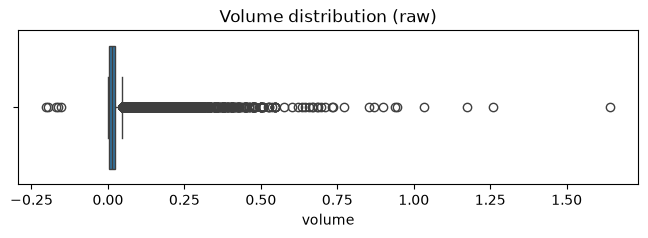

In [71]:
plt.figure(figsize=(8, 2))
sns.boxplot(x=logistics_df['volume'])
plt.title('Volume distribution (raw)')
plt.show()

Q4. Is volume consistent with quantity?

In [67]:
print(logistics_df[['volume', 'wm_vsola']].corr())


            volume  wm_vsola
volume    1.000000  0.840505
wm_vsola  0.840505  1.000000


In [69]:
# Volume per unit should be roughly constant for each product
logistics_df['vol_per_unit'] = logistics_df['volume'] / logistics_df['wm_vsola']   # temporary

per_product = logistics_df.groupby('product_id')['vol_per_unit'].agg(['min', 'median', 'max'])
print(per_product.sort_values('min').head(10))

logistics_df = logistics_df.drop(columns='vol_per_unit')   # remove the temporary column


               min    median       max
product_id                            
product_107 -0.201  0.001750  0.002229
product_115 -0.153  0.003800  0.004576
product_83  -0.085  0.001333  0.002000
product_11   0.000  0.002667  0.003000
product_111  0.000  0.004400  0.005000
product_122  0.000  0.002000  0.002000
product_124  0.000  0.001313  0.001500
product_0    0.000  0.003000  0.003143
product_12   0.000  0.004000  0.004000
product_120  0.000  0.004000  0.004000


### Volume: Key Insights
- **Format:** Numeric once the comma decimal is read correctly, with no missing values. Most picks are small (median 0.013).
- **Invalid values:** 5 negative rows are corrections logged seconds after a large pick of the same product in the same colli (`wm_tapos = 2`). 199 zero rows have normal quantities, so their volume is missing, not rounded. Together they are about 0.1% of rows.
- **Extremes:** Volume is heavily right-skewed (99% ≤ 0.143, max 1.642). The largest values match large quantities, so they are genuine bulk picks, but half of the top 10 come from `colli_6599`. Use the median, not the mean.
- **Consistency:** Volume tracks quantity closely (r = 0.84), so it is a reliable measure of physical workload.
- **Decision:** Keep the column. Handle the 5 corrections and 199 missing values during cleaning.

c. Colli_id

d. Picker


## e. wm_vsola(Quantity)

# f. calday / calweek

# g. Start_time


# h. Finish_time

# i. Product_id

# j. wm_tapos

# 1. Data Cleaning
## 1.1 Check structure abd datatypes

In [44]:
logistics_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 217963 entries, 0 to 217962
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   location     217963 non-null  str    
 1   volume       217963 non-null  str    
 2   picker       217963 non-null  str    
 3   wm_vsola     217963 non-null  str    
 4   area         217963 non-null  str    
 5   warehouse    217963 non-null  str    
 6   calday       217963 non-null  str    
 7   calweek      217963 non-null  int64  
 8   calmonth     217963 non-null  str    
 9   calyear      217963 non-null  str    
 10  collli_id    217963 non-null  str    
 11  start_time   217869 non-null  str    
 12  finish_time  217963 non-null  str    
 13  wm_srsrc     0 non-null       float64
 14  wm_vltyp     217963 non-null  int64  
 15  product_id   217963 non-null  str    
 16  wm_qdocno    1 non-null       float64
 17  wm_tapos     217963 non-null  int64  
dtypes: float64(2), int64(3), str(13)
me

## 1.2 Data Type Conversion

The raw dataset contains several columns stored in incorrect formats (e.g., numeric and date fields saved as text). 

In this step, numeric columns such as `volume` and `wm_vsola` are converted to proper numeric types, and date/time fields (`calday`, `start_time`, `finish_time`) are converted to datetime format. 

This ensures accurate calculations, especially for duration analysis and future aggregations.

In [45]:
df = logistics_data.copy()

# 1️. Fix Volume (comma decimal → dot)
df["volume"] = df["volume"].str.replace(",", ".", regex=False)
df["volume"] = pd.to_numeric(df["volume"], errors="coerce")

# 2️. Convert wm_vsola to numeric
df["wm_vsola"] = pd.to_numeric(df["wm_vsola"], errors="coerce")

# 3️. Convert date columns
df["calday"] = pd.to_datetime(df["calday"], errors="coerce")
df["calmonth"] = pd.to_datetime(df["calmonth"], errors="coerce")
df["calyear"] = pd.to_datetime(df["calyear"], errors="coerce")

# 4️. Convert timestamps
df["start_time"] = pd.to_datetime(df["start_time"], errors="coerce")
df["finish_time"] = pd.to_datetime(df["finish_time"], errors="coerce")

print("Data types after conversion:\n")
print(df.dtypes)

print("\nMissing values check (top 10):")
print(df.isna().sum().sort_values(ascending=False).head(10))

Data types after conversion:

location                  str
volume                float64
picker                    str
wm_vsola              float64
area                      str
warehouse                 str
calday         datetime64[us]
calweek                 int64
calmonth       datetime64[us]
calyear        datetime64[us]
collli_id                 str
start_time     datetime64[us]
finish_time    datetime64[us]
wm_srsrc              float64
wm_vltyp                int64
product_id                str
wm_qdocno             float64
wm_tapos                int64
dtype: object

Missing values check (top 10):
wm_srsrc      217963
wm_vsola      217963
wm_qdocno     217962
start_time        94
volume             0
location           0
calday             0
picker             0
area               0
warehouse          0
dtype: int64


## 1.3 Create Picking Duration and Remove Invalid Records


In [46]:
# 1. create duration in seconds
df["duration_sec"] = (df["finish_time"] - df["start_time"]).dt.total_seconds()

print("shape before cleaning", df.shape)

shape before cleaning (217963, 19)


In [47]:
# 2. remove rows with missing start_time
df = df[df["start_time"].notna()]

# 3. remove zero or negative durations
df = df[df["duration_sec"] > 0]

print("shape after cleaning", df.shape)

# Check how many rows were removed
print("Rows removed:", logistics_data.shape[0] - df.shape[0])

shape after cleaning (208089, 19)
Rows removed: 9874


In this step, we calculate the picking duration in seconds using the difference between `finish_time` and `start_time`.

Records with missing timestamps or non-positive durations are removed, as they likely represent system errors or invalid scanning activity. 

This ensures that the dataset reflects only valid picking tasks for accurate analysis.

## 1.4 Fix Invalid Volume Values


In [48]:
#count zero or negative volume values
invalid_volumes = (df["volume"] <= 0).sum()

print("Number of invalid volumes :", invalid_volumes)

Number of invalid volumes : 201


In [49]:
# 1. Set invalid volumes to NaN
df.loc[df["volume"] <= 0, "volume"] = np.nan

# Check missing volume before imputation
print("Missing volume before:", df["volume"].isna().sum())


Missing volume before: 201


In [50]:
# 2. Impute using median volume per product
df["volume"] = df.groupby("product_id") ["volume"]\
                    .transform(lambda x:x.fillna(x.median()))

# Check missing volume after
print("Missing volume after:", df["volume"].isna().sum())

Missing volume after: 0


Volume is a key operational variable influencing picking duration.

Invalid values (zero, negative, or missing) are replaced using the median volume within each product group. This approach preserves product-specific size characteristics, since different products (e.g., apples vs. bananas) naturally vary in volume. Using product-level medians ensures more realistic and operationally meaningful estimates compared to applying a global average.


## 1.5 Create Analytical Features

In [51]:
# 1️. Extract Date from start_time
df["date"] = df["start_time"].dt.date

# 2️. Weekday Name
df["weekday_name"] = df["start_time"].dt.day_name()

# 3️. Weekend Flag
df["is_weekend"] = df["weekday_name"].isin(["Saturday", "Sunday"])

# 4️. Extract Location Components
df["location_row"] = df["location"].str[3:5].astype(int)
df["location_id"] = df["location"].str[6:9].astype(int)

print("New columns added successfully.")

New columns added successfully.


In [52]:
print(df[["date", "weekday_name", "is_weekend", "location_row", "location_id"]].head())

         date weekday_name  is_weekend  location_row  location_id
0  2023-04-01     Saturday        True             6           36
1  2023-04-01     Saturday        True             6           36
2  2023-04-01     Saturday        True             6           36
3  2023-04-01     Saturday        True             6           36
4  2023-04-01     Saturday        True             6           36


Additional analytical fields are created to support business reporting and warehouse modeling.

Date-related fields enable time-based analysis (weekday trends and weekend comparison), while location components allow performance evaluation by warehouse zone. These features will later form the basis of dimension tables in the data warehouse.

In [53]:
print(df.head())

      location  volume    picker  wm_vsola    area    warehouse     calday  \
0  10-06-036-1   0.003  picker_0       NaN  area_0  warehouse_0 2023-04-01   
1  10-06-036-1   0.003  picker_1       NaN  area_0  warehouse_0 2023-04-01   
2  10-06-036-1   0.003  picker_2       NaN  area_0  warehouse_0 2023-04-01   
3  10-06-036-1   0.003  picker_3       NaN  area_0  warehouse_0 2023-04-01   
4  10-06-036-1   0.003  picker_4       NaN  area_0  warehouse_0 2023-04-01   

   calweek   calmonth    calyear  ... wm_vltyp product_id wm_qdocno  wm_tapos  \
0   202313 2023-04-01 2023-01-01  ...       50  product_0       NaN         1   
1   202313 2023-04-01 2023-01-01  ...       50  product_0       NaN         1   
2   202313 2023-04-01 2023-01-01  ...       50  product_0       NaN         1   
3   202313 2023-04-01 2023-01-01  ...       50  product_0       NaN         1   
4   202313 2023-04-01 2023-01-01  ...       50  product_0       NaN         1   

   duration_sec        date  weekday_name  i

## 1.6 Remove Unnecessary Columns
To simplify the dataset for analytical and BI purposes, we remove system-generated and non-informative columns. 

Columns such as `area`, `warehouse`, `wm_srsrc`, `wm_qdocno`, and `wm_tapos` do not contribute to operational performance analysis and are therefore excluded. 

Key operational variables like `product_id`, `collli_id`, `wm_vsola`, and location identifiers are retained to allow deeper analysis if needed.

In [54]:
# Drop columns that are not useful for BI/analytics
columns_to_drop = [
    "area",
    "warehouse",
    "calweek",
    "calmonth",
    "calyear",
    "wm_tapos",
    "wm_srsrc",   # all missing
    "wm_qdocno"   # almost all missing
]

df = df.drop(columns=columns_to_drop)

print("Remaining columns:")
print(df.columns.tolist())


Remaining columns:
['location', 'volume', 'picker', 'wm_vsola', 'calday', 'collli_id', 'start_time', 'finish_time', 'wm_vltyp', 'product_id', 'duration_sec', 'date', 'weekday_name', 'is_weekend', 'location_row', 'location_id']


## 1.7 Export Clean Analytical Dataset

After cleaning and removing unnecessary columns, the dataset is ready for analytical use.

The cleaned dataset will serve as the staging layer for SQL data warehouse modeling and Power BI reporting. This ensures consistent and reproducible data transformations.

In [55]:
# Final dataset shape
print("Final dataset shape:", df.shape)

# Save clean dataset inside data folder
df.to_csv("data/clean_picking_data.csv", index=False)

print("Clean dataset saved in data/ folder")

Final dataset shape: (208089, 16)


OSError: Cannot save file into a non-existent directory: 'data'

## 1.8 Connect to database

In [ ]:
#install packages
!pip install sqlalchemy psycopg2-binary pandas

In [ ]:
# connect jupyter to PostgreSQL
from sqlalchemy import create_engine

# Databse connection details
username = os.getenv("PG_USER")
password = os.getenv("PG_PASSWORD")
host = os.getenv("PG_HOST")
port = os.getenv("PG_PORT")
database = os.getenv("PG_DATABASE")

# Create PostgreSQL engine
engine = create_engine(f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}")

# test connection
with engine.connect() as conn:
    print("Connected to PostgreSQL!")

In [ ]:
# load dataframe to Postgres
df = pd.read_csv("data/clean_picking_data.csv")

# Load into public schema/table (auto-creates table)
df.to_sql(
    "clean_picking_data",
    engine,
    schema="public",
    if_exists="replace",   # use "append" if we want to add rows later
    index=False
)

print("Loaded into PostgreSQL: database.clean_picking_data")

The cleaned dataset is loaded into PostgreSQL to establish a structured data warehouse environment. This enables SQL-based modeling and prepares the data for dimensional design and BI reporting.